# Phase 5: Exploratory Data Analysis (EDA)
This notebook explores the cleaned 250-record IT recruitment dataset across five dimensions:

1. **Job Market Landscape** - Distribution of job postings by domain and hiring location
2. **Salary Benchmarks** - Median salary ranges by domain, with a note on imputation methodology
3. **Skill Demand** - Top 5 most requested skills per job domain
4. **Language Advantage** - Whether foreign language requirements correlate with higher compensation
5. **Skill Co-occurrence** - Which technical skills are most frequently bundled together in a single job posting

In [65]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import itertools

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

df = pd.read_csv('../data/04_processed/it_recruitment_processed.csv')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6248\259778753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=domain_counts, x='Count', y='Job Domain', palette='viridis')


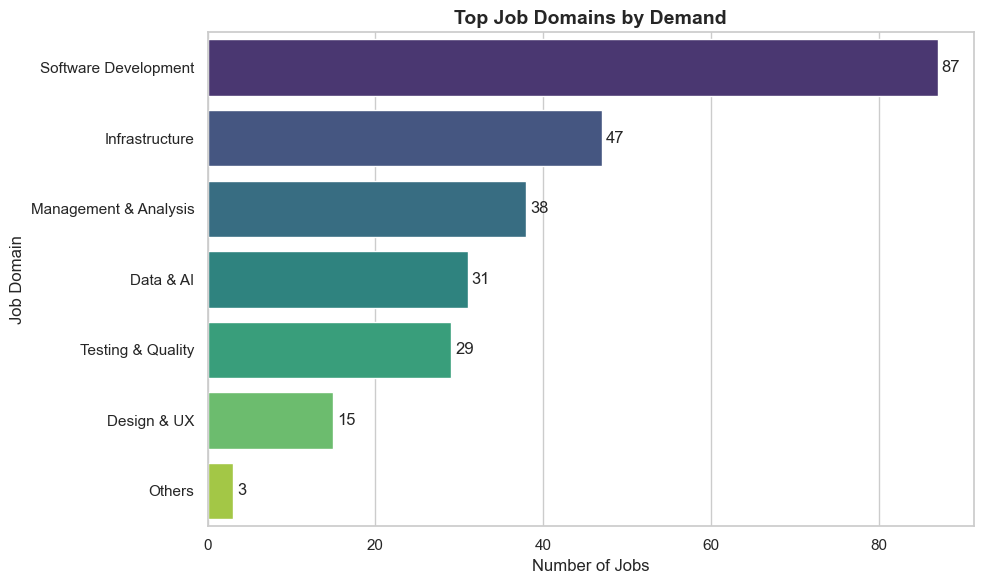

In [ ]:
# Top Job Domains by Demand
plt.figure(figsize=(10, 6))

domain_counts = df['Job Domain'].value_counts().reset_index()
domain_counts.columns = ['Job Domain', 'Count']

ax = sns.barplot(data=domain_counts, x='Count', y='Job Domain', palette='viridis')
plt.title('Top Job Domains by Demand', fontsize=14, fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('Job Domain')

for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.tight_layout()
plt.show()

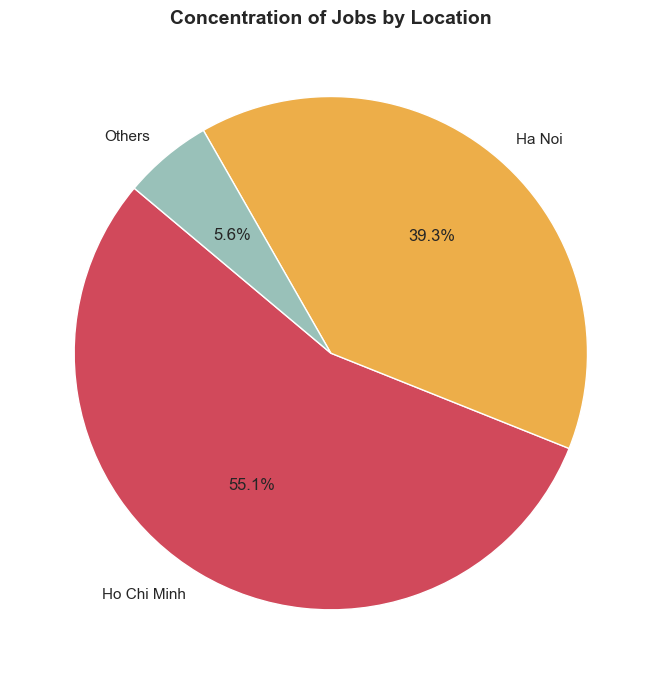

In [ ]:
# Location Distribution
df['Location_List'] = df['Location'].apply(
    lambda x: [loc.strip() for loc in str(x).split(',')] if pd.notna(x) else []
)
df_exploded = df.explode('Location_List')
df_exploded = df_exploded[df_exploded['Location_List'] != 'nan']

def group_location(loc):
    if loc == 'Ha Noi':      return 'Ha Noi'
    if loc == 'Ho Chi Minh': return 'Ho Chi Minh'
    return 'Others'

df_exploded['Location_Group'] = df_exploded['Location_List'].apply(group_location)
loc_counts = df_exploded['Location_Group'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    loc_counts,
    labels=loc_counts.index,
    autopct='%1.1f%%',
    colors=['#d1495b', '#edae49', '#99c1b9'],
    startangle=140
)
plt.title('Concentration of Jobs by Location', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Data Limitation: Salary Insights

Only **~25%** of job postings contained explicit salary figures. The remaining **75%** used non-numeric disclosures such as *"Negotiable"*, *"Competitive"*, or *"Thỏa thuận"*, which is common in the Vietnamese IT labor market.

**Imputation Strategy**
Missing values were filled using Nearest-Neighbor Median Imputation, grouping by `Job Domain` and selecting reference jobs within a ±1 year experience window.

**Implications**
- Salary figures reflect a statistically estimated distribution for macro-level analysis, not exact employer compensation.
- Median imputation reduces sensitivity to extreme values; salary variations hidden under non-disclosure labels may not be fully captured.
- Despite this limitation, the approach follows standard practice for recruitment datasets with high missing-data rates and supports valid comparison across job domains.

In [69]:
df['Salary_Mean'] = df[['Salary_Min_VND', 'Salary_Max_VND']].mean(axis=1)

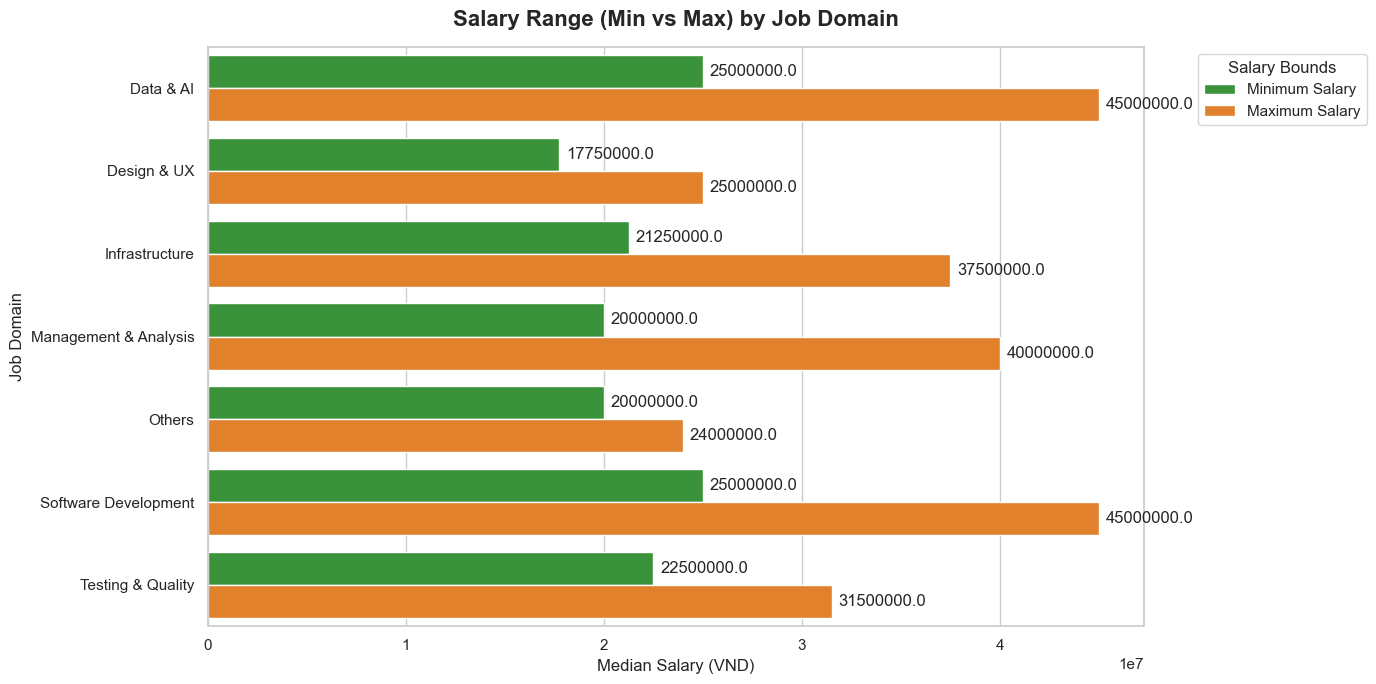

In [ ]:
# Salary Range (Min vs Max) by Job Domain
df_salary_range = df.melt(id_vars=['Job Domain'],
                          value_vars=['Salary_Min_VND', 'Salary_Max_VND'],
                          var_name='Salary_Type',
                          value_name='Salary_VND')

df_salary_range = df_salary_range.dropna(subset=['Salary_VND'])

df_salary_range['Salary_Type'] = df_salary_range['Salary_Type'].map({
    'Salary_Min_VND': 'Minimum Salary',
    'Salary_Max_VND': 'Maximum Salary'
})

plt.figure(figsize=(14, 7))

ax = sns.barplot(data=df_salary_range,
                 x='Salary_VND',
                 y='Job Domain',
                 hue='Salary_Type',
                 estimator=np.median,
                 errorbar=None,
                 palette=['#2ca02c', '#ff7f0e'])

plt.title('Salary Range (Min vs Max) by Job Domain', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Median Salary (VND)', fontsize=12)
plt.ylabel('Job Domain', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5)

plt.legend(title='Salary Bounds', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6248\1424862133.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


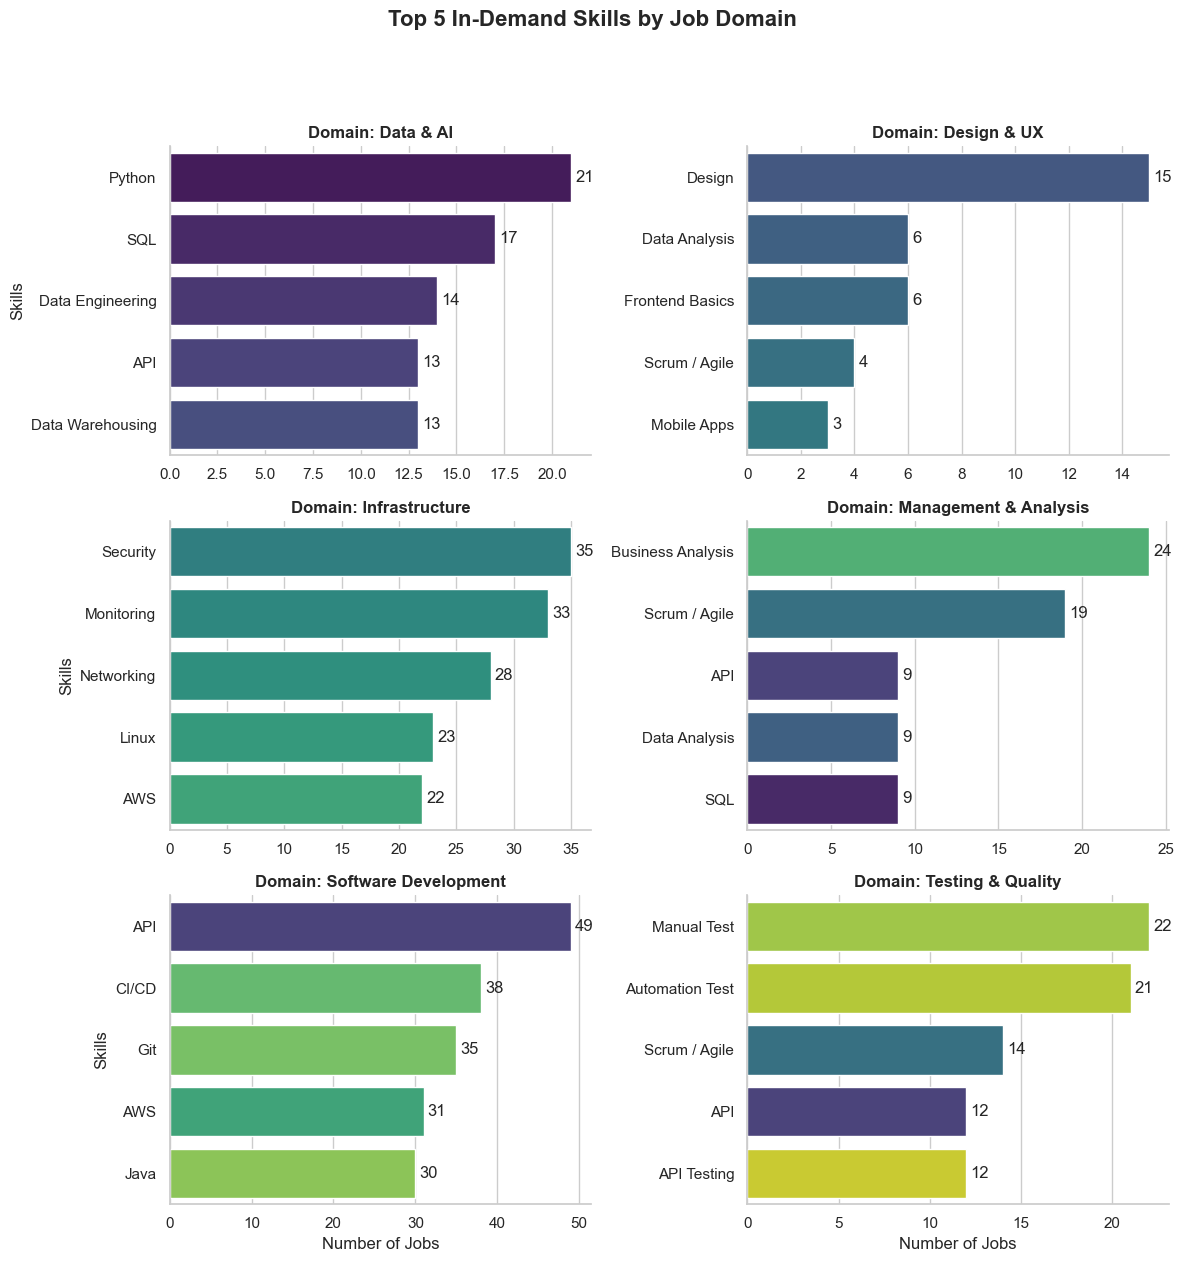

In [ ]:
# Presentation of Top 5 In-Demand Skills by Job Domain
df_exploded_skills = df.copy()
df_exploded_skills = df_exploded_skills.dropna(subset=['Skills'])
df_exploded_skills['Skill_List'] = df_exploded_skills['Skills'].apply(
    lambda x: [s.strip() for s in str(x).split(',') if s.strip() != '']
)
df_exploded_skills = df_exploded_skills.explode('Skill_List')

df_filtered = df_exploded_skills[df_exploded_skills['Job Domain'] != 'Others']

skill_counts = df_filtered.groupby(['Job Domain', 'Skill_List']).size().reset_index(name='Count')

top_skills_per_domain = skill_counts.sort_values(['Job Domain', 'Count'], ascending=[True, False])
top_skills_per_domain = top_skills_per_domain.groupby('Job Domain').head(5)

g = sns.catplot(
    data=top_skills_per_domain,
    x='Count', y='Skill_List', col='Job Domain',
    kind='bar', col_wrap=2, sharey=False, sharex=False,
    palette='viridis', height=4, aspect=1.5
)

g.fig.suptitle('Top 5 In-Demand Skills by Job Domain', y=1.05, fontsize=16, fontweight='bold')
g.set_axis_labels('Number of Jobs', 'Skills')
g.set_titles('Domain: {col_name}', fontweight='bold')

for ax in g.axes.flat:
    for i in ax.containers:
        ax.bar_label(i, padding=3)

plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6248\1676306254.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cross_tab_pct = cross_tab.div(cross_tab.sum(1), axis=0) * 100


<Figure size 1400x800 with 0 Axes>

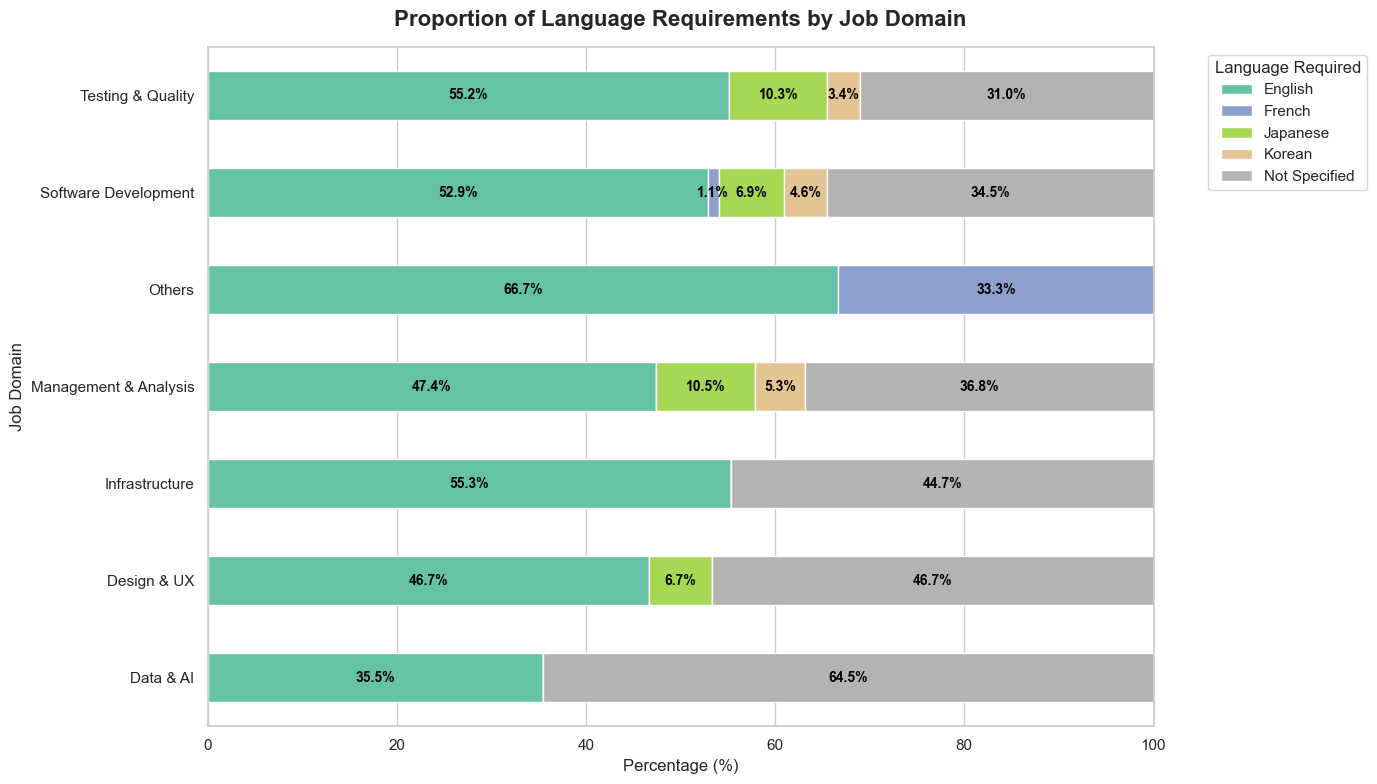

In [ ]:
# Proportion of Language Requirements by Job Domain
df_lang = df.copy()
df_lang['Language Requirement'] = df_lang['Language Requirement'].fillna('Not Specified')

cross_tab = pd.crosstab(df_lang['Job Domain'], df_lang['Language Requirement'])
cross_tab_pct = cross_tab.div(cross_tab.sum(1), axis=0) * 100

plt.figure(figsize=(14, 8))
ax = cross_tab_pct.plot(kind='barh', stacked=True, colormap='Set2', edgecolor='white', figsize=(14, 8))

plt.title('Proportion of Language Requirements by Job Domain', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Job Domain', fontsize=12)
plt.xlim(0, 100)

for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='black')

plt.legend(title='Language Required', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6248\2610602969.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lang_salary, x='Lang_Status', y='Salary_Mean',


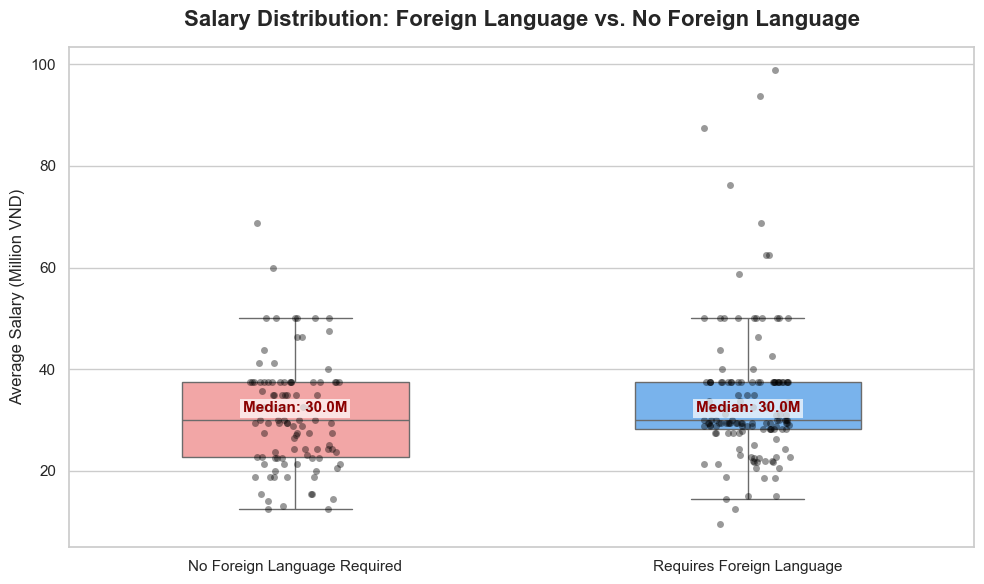

In [ ]:
# Salary Distribution: Foreign Language vs. No Foreign Language
df_lang_salary = df.copy()
df_lang_salary['Salary_Mean'] = df_lang_salary[['Salary_Min_VND', 'Salary_Max_VND']].mean(axis=1) / 1e6
df_lang_salary = df_lang_salary.dropna(subset=['Salary_Mean'])

df_lang_salary['Lang_Status'] = df_lang_salary['Language Requirement'].apply(
    lambda x: 'No Foreign Language Required' if pd.isna(x) or str(x).strip() == '' else 'Requires Foreign Language'
)

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_lang_salary, x='Lang_Status', y='Salary_Mean',
            palette=['#ff9999', '#66b3ff'], width=0.5, showfliers=False)

sns.stripplot(data=df_lang_salary, x='Lang_Status', y='Salary_Mean',
              color='black', alpha=0.4, jitter=True, size=5)

plt.title('Salary Distribution: Foreign Language vs. No Foreign Language', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('Average Salary (Million VND)', fontsize=12)

medians = df_lang_salary.groupby('Lang_Status')['Salary_Mean'].median()
for i, status in enumerate(['No Foreign Language Required', 'Requires Foreign Language']):
    if status in medians:
        median_val = medians[status]
        plt.text(i, median_val + 1.5, f'Median: {median_val:.1f}M',
                 horizontalalignment='center', fontweight='bold', color='darkred', fontsize=11,
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

plt.tight_layout()
plt.show()

In [ ]:
# Table of Top 30 Most Frequently Co-Occurring Skill Pairs
df_pairs = df.copy()
df_pairs = df_pairs.dropna(subset=['Skills'])
df_pairs['Skill_List'] = df_pairs['Skills'].apply(
    lambda x: sorted(list(set([s.strip() for s in str(x).split(',') if s.strip() != ''])))
)

pair_counts = Counter()
for skills in df_pairs['Skill_List']:
    if len(skills) >= 2:
        for pair in itertools.combinations(skills, 2):
            pair_counts[pair] += 1

pairs_df = pd.DataFrame([
    {'Skill_1': pair[0], 'Skill_2': pair[1], 'Co_occurrence_Count': count}
    for pair, count in pair_counts.items()
])
pairs_df = pairs_df.sort_values(by='Co_occurrence_Count', ascending=False).reset_index(drop=True)

print('TOP 30 MOST FREQUENTLY CO-OCCURRING SKILL PAIRS')
print('=' * 55)
print(f'{"#":<5} {"Skill 1":<20} {"Skill 2":<20} {"Jobs":>6}')
print('-' * 55)
for index, row in pairs_df.head(30).iterrows():
    print(f'{index + 1:<5} {row["Skill_1"]:<20} {row["Skill_2"]:<20} {row["Co_occurrence_Count"]:>6}')
print('=' * 55)

TOP 30 MOST FREQUENTLY CO-OCCURRING SKILL PAIRS
#     Skill 1              Skill 2                Jobs
-------------------------------------------------------
1     AWS                  CI/CD                    44
2     API                  CI/CD                    41
3     CI/CD                Docker                   41
4     AWS                  Azure                    36
5     API                  Microservices            35
6     CI/CD                Microservices            34
7     AWS                  Docker                   34
8     Docker               Kubernetes               34
9     AWS                  Security                 33
10    AWS                  GCP                      33
11    API                  AWS                      32
12    API                  Docker                   31
13    CI/CD                Python                   31
14    CI/CD                Security                 31
15    API                  Git                      31
16    API       

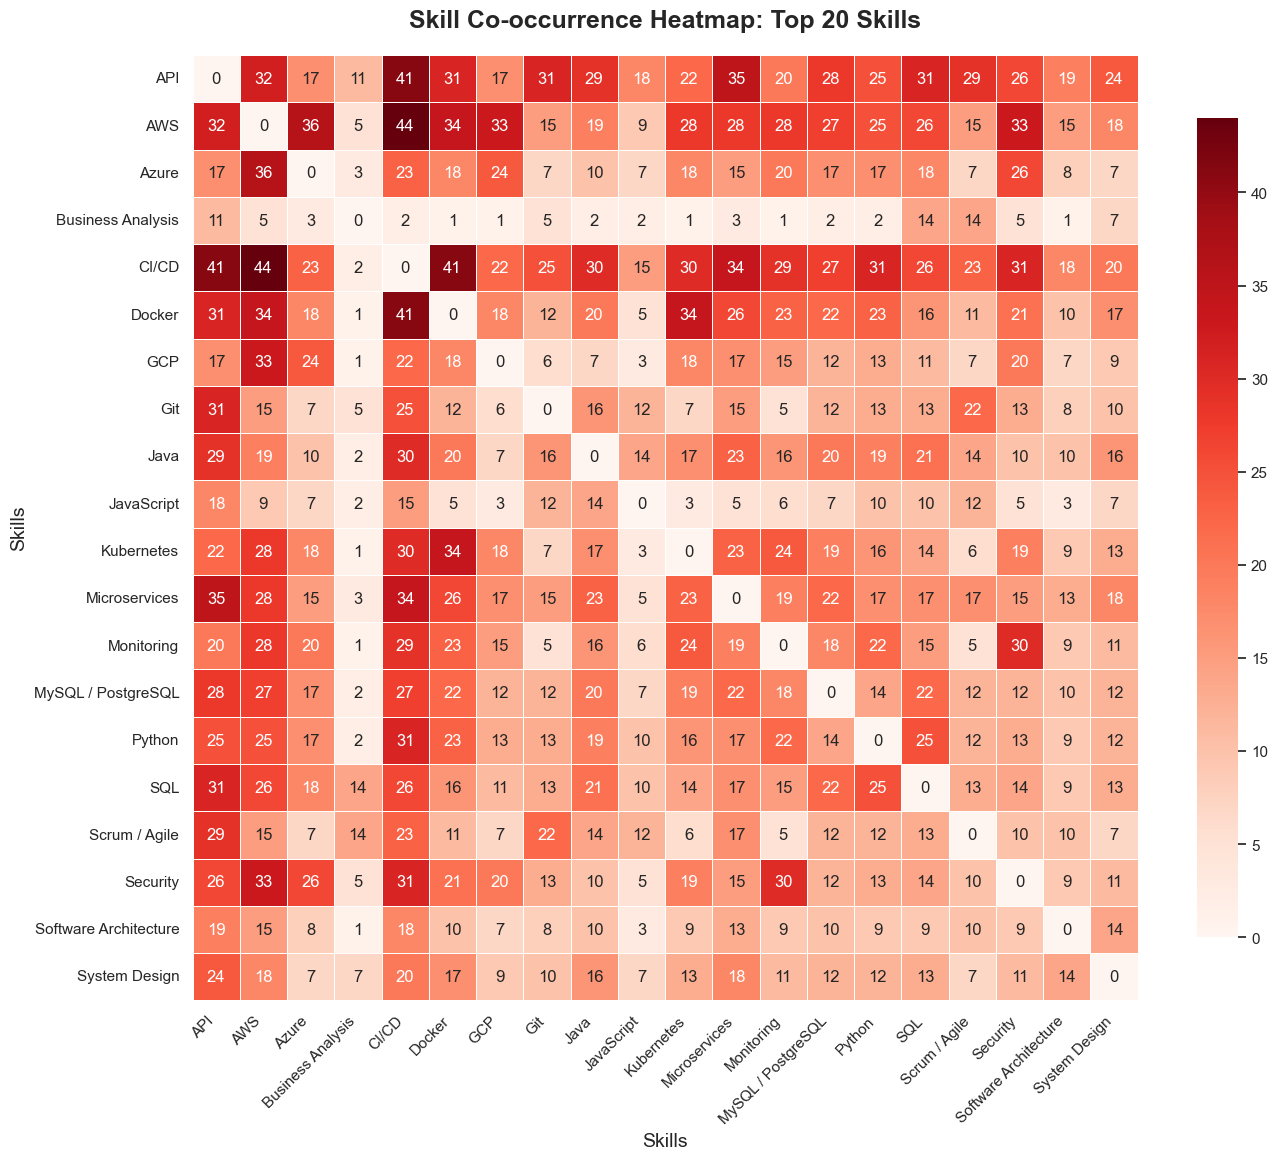

In [ ]:
# Heatmap of skill co-occurrence for top 20 skills
df_co = df.copy()
df_co = df_co.dropna(subset=['Skills'])
df_co['Skill_List'] = df_co['Skills'].apply(lambda x: [s.strip() for s in str(x).split(',') if s.strip() != ''])
df_co['Job_ID'] = range(len(df_co))
df_exploded_co = df_co.explode('Skill_List').reset_index(drop=True)

top_20_skills = df_exploded_co['Skill_List'].value_counts().head(20).index.tolist()
df_top = df_exploded_co[df_exploded_co['Skill_List'].isin(top_20_skills)]

skill_matrix = pd.crosstab(df_top['Job_ID'], df_top['Skill_List'])
skill_matrix = skill_matrix.clip(upper=1)

co_occurrence = skill_matrix.T.dot(skill_matrix)
for skill in co_occurrence.columns:
    co_occurrence.loc[skill, skill] = 0

plt.figure(figsize=(14, 12))

sns.heatmap(co_occurrence,
            cmap='Reds',
            annot=True,
            fmt='d',
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": .8})

plt.title('Skill Co-occurrence Heatmap: Top 20 Skills', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Skills', fontsize=14)
plt.ylabel('Skills', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [1]:
%pip install git

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement git (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for git
